### 6. Двунаправленные рекуррентные нейронные сети

Когда решается задача анализа уже целой последовательности слов (например, для оценки семантической окраски фразы), можно как бы просканировать всю фразу целиком, пройдясь по ней сначала в одну сторону, а затем в обратную. Это делается, чтобы получить дополнительную информацию о сущности подаваемой на вход информации. Для нейросетей это имеет смысл, хотя и кажется на первой взгляд неочевидным.

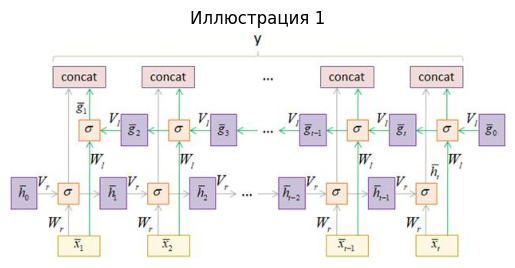

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image1 = mpimg.imread('illustrations/RNN_bidirectional.jpg')

plt.imshow(image1)
plt.axis('off')
plt.title('Иллюстрация 1')
plt.show()

Реализуем базовую модель двунаправленной рекуррентной нейронной сети:

In [2]:
import torch
import torch.nn as nn

class WordsRNN(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.hidden_layer = 16
        self.in_features = in_features
        self.out_features = out_features

        self.rnn = nn.RNN(self.in_features, self.hidden_layer, batch_first=True, bidirectional=True)
        self.out = nn.Linear(self.hidden_layer * 2, self.out_features)

    def forward(self, x):
        x, h = self.rnn(x)
        y = self.out(torch.cat((h[-2, :, :], h[-1, :, :]), dim=1))
        return y

И DataLoader для неё. Необходимо учесть, что последовательнсоти в датасете имеют разную длину. В таком случае, необходимо сгруппировать их в батчи по длине, а недостающие символы заменить нулями:

In [3]:
import torch.utils.data as data
import re

class PhraseDataset(data.Dataset):
    def __init__(self, path_true, path_false, navec_emb, batch_size=8):
        self.navec_emb = navec_emb
        self.batch_size = batch_size

        with open(path_true, 'r', encoding='utf-8') as f:
            phrase_true = f.readlines()
            self._clear_phrase(phrase_true)

        with open(path_false, 'r', encoding='utf-8') as f:
            phrase_false = f.readlines()
            self._clear_phrase(phrase_false)

        self.phrase_lst = [(_x, 0) for _x in phrase_true] + [(_x, 1) for _x in phrase_false]
        self.phrase_lst.sort(key=lambda _x: len(_x[0]))
        self.dataset_len = len(self.phrase_lst)

    def _clear_phrase(self, p_lst):
        for _i, _p in enumerate(p_lst):
            _p = _p.lower().replace('\ufeff', '').strip()
            _p = re.sub(r'[^А-яA-z- ]', '', _p)
            _words = _p.split()
            _words = [w for w in _words if w in self.navec_emb]
            p_lst[_i] = _words

    def __getitem__(self, item):
        item *= self.batch_size
        item_last = item + self.batch_size
        if item_last > self.dataset_len:
            item_last = self.dataset_len

        _data = []
        _target = []
        max_length = len(self.phrase_lst[item_last-1][0])

        for i in range(item, item_last):
            words_emb = []
            phrase = self.phrase_lst[i]
            length = len(phrase[0])

            for k in range(max_length):
                t = torch.tensor(self.navec_emb[phrase[0][k]], dtype=torch.float32) if k < length else torch.zeros(300)
                words_emb.append(t)

            _data.append(torch.vstack(words_emb))
            _target.append(torch.tensor(phrase[1], dtype=torch.float32))

        _data_batch = torch.stack(_data)
        _target = torch.vstack(_target)
        return _data_batch, _target

    def __len__(self):
        last = 0 if self.dataset_len % self.batch_size == 0 else 1
        return self.dataset_len // self.batch_size + last

Делаем стандартные настройки перед запуском обучающего цикла:

In [4]:
from navec import Navec
import torch.optim as optim

path = 'weights/embeddings_navec/navec_hudlit_v1_12B_500K_300d_100q.tar'
navec = Navec.load(path)

d_train = PhraseDataset('datasets/rnn/train_data_true', 'datasets/rnn/train_data_false', navec)
train_data = data.DataLoader(d_train, batch_size=1, shuffle=True)

Сам обучающий цикл:

In [5]:
from tqdm import tqdm

def model_train(model, epochs):
    optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=0.001)
    loss_func = nn.BCEWithLogitsLoss()
    model.train()
    width = len(str(epochs))

    for _e in range(epochs):
        loss_mean = 0
        lm_count = 0
        
        train_tqdm = tqdm(train_data, leave=True)
        for x_train, y_train in train_tqdm:
            predict = model(x_train.squeeze(0)).squeeze(0)
            loss = loss_func(predict, y_train.squeeze(0))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            lm_count += 1
            loss_mean = 1/lm_count * loss.item() + (1 - 1/lm_count) * loss_mean
            train_tqdm.set_description(f'Epoch [{_e+1:>{width}d}/{epochs}], loss_mean={loss_mean:.3f}')

    model.eval()

model = WordsRNN(300, 1)
model_train(model, 20)

st = model.state_dict()
torch.save(st, 'weights/rnn/model_rnn_bidir.tar')

Epoch [20/20], loss_mean=0.018: 100%|██████████| 22/22 [00:00<00:00, 103.42it/s]


Инференс:

In [6]:
phrase = "Сегодня плохая погода"
phrase_lst = phrase.lower().split()
phrase_lst = [torch.tensor(navec[w]) for w in phrase_lst if w in navec]
_data_batch = torch.stack(phrase_lst)
predict = model(_data_batch.unsqueeze(0)).squeeze(0)
p = torch.nn.functional.sigmoid(predict).item()

print(p)
print(phrase, ":", "положительное" if p < 0.5 else "отрицательное")

0.6759629249572754
Сегодня плохая погода : отрицательное


### 7. Понятие LSTM

Результат неудовлетворительный. Дело в том, что нейросеть обрщает внимание на все слова одинаково. Тем не менее, в фразе есть наиболее влияющие слова, которая определяет контекст. Пример «Я очень люблю программировать, …, поэтому в будущем хочу стать программистом.», сеть должна улавливать, что речь идет именно о программировании, а незначительный текст следует опустить. Такой функицонал реалузуется, например, при помощи LSTM.

В базовом исполнении рекуррентный LSTM слой можно изобразить следующим образом:

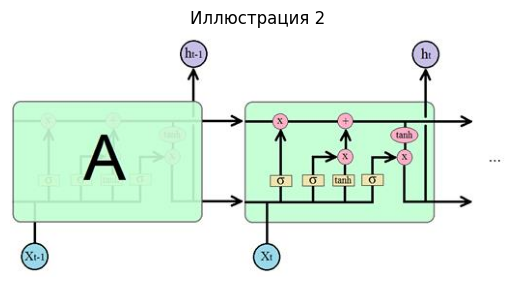

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image2 = mpimg.imread('illustrations/LSTM.jpg')

plt.imshow(image2)
plt.axis('off')
plt.title('Иллюстрация 2')
plt.show()

Отличительной чертой архитектуры LSTM является наличие вот этой верхней связи, по которой, как бы движется вектор контекста (буква C – от слова context):

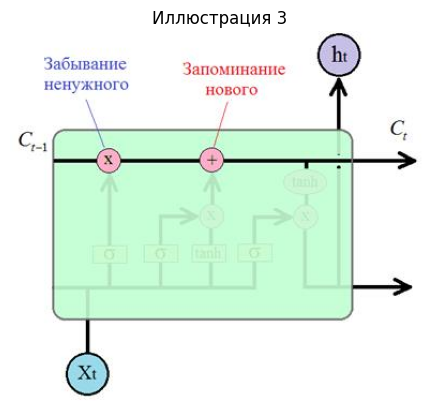

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image3 = mpimg.imread('illustrations/LSTM_context.jpg')

plt.imshow(image3)
plt.axis('off')
plt.title('Иллюстрация 3')
plt.show()

Благодаря ее наличию LSTM-блок имеет возможность сохранять и передавать долгосрочный контекст дальше по рекурсии. Естественно, возникают вопросы: как и почему при поэлементном умножении происходит забывание чего-то ненужного, а при поэлементном сложении – запоминание чего-то нового? Сначала разберемся с забыванием. На вход операции умножения поступают два вектора: один $C_{t-1}$ (вектор контекста), а второй - $f_{t}$ (оценочный вектор):

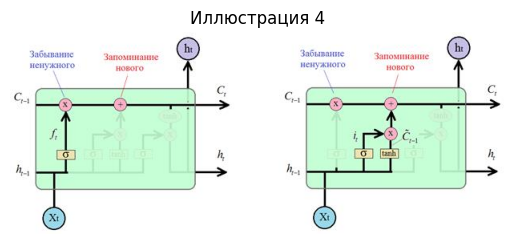

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image4 = mpimg.imread('illustrations/LSTM_context_extended.jpg')

plt.imshow(image4)
plt.axis('off')
plt.title('Иллюстрация 4')
plt.show()

Из этого рисунка видно, что вектор $f_t$ образуется как выход полносвязного слоя с сигмоидальной функцией активации:

$$ f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) $$

Здесь $W_f$ — весовые коэффициенты этого слоя; $[h_{t-1}, x_t]$ — объединенный вектор из двух векторов; $b_f$ — смещение (bias); $\sigma()$ — игмоидальная функция (на выходе дает диапазон [0; 1]). В результате, вектор $f_t$ будет состоять из чисел от 0 до 1 и иметь ту же размерность, что и вектор контекста $C_{t-1}$:

$$
f_t = [0, 2; 0, 3; 0, 9; 0, 1; 0, 5, \dots]^T
$$

И при поэлементном умножении из вектора $C_{t-1}$ будут убираться незначимые, с точки зрения блока LSTM, величины. Но все-таки, откуда сеть может знать: что оставить, а что нет? Как раз это определяется в процессе ее обучения, то есть, подбором весовых коэффициентов $W_f$. Правильно обученная сеть будет, в среднем, корректно ослаблять ненужные величины вектора долгосрочного контекста $C_{t-1}$ и оставлять значимые.

Теперь посмотрим, как происходит обновление контекста при поэлементном сложении. То, что сеть будет добавлять, формируется по только что описанному принципу. Сначала вычисляется оценочный вектор и вектор контекста для текущего элемента $x_t$ и предыдущего скрытого состояния $h_{t-1}$:

$$ i_t = \sigma(W_p \cdot [h_{t-1}, x_t] + b_i) $$

$$ \tilde{C}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c) $$

а, затем, они поэлементно умножаются:

$$ a_{_I} = i_{_I}\otimes \tilde{C}_{_I} $$

Благодаря этому умножению из вектора добавочного контекста будет удаляться ненужная для долгосрочного запоминания информация. И, далее, сформированный вектор $a_t$ поэлементно сложится с вектором $C_{t-1}$:

$$ C_i = f_i \otimes C_{i-1} + a_i $$

Так в блоке LSTM меняется долгосрочный контекст от итерации к итерации.

Теперь попробуем улучшить результат нейросети при помощи введения LSTM — долгой краткосрочной памяти модели:

In [10]:
class WordsRNN(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.hidden_layer = 16
        self.in_features = in_features
        self.out_features = out_features

        self.rnn = nn.LSTM(self.in_features, self.hidden_layer, batch_first=True, bidirectional=True)
        self.out = nn.Linear(self.hidden_layer * 4, self.out_features)

    def forward(self, x):
        x, (h, c) = self.rnn(x)
        y = self.out(torch.cat((h[-2, :, :], h[-1, :, :], c[-1, :, :], c[-1, :, :]), dim=1))
        return y

model = WordsRNN(300, 1)
model_train(model, 20)

st = model.state_dict()
torch.save(st, 'weights/rnn/model_rnn_bidir_LSTM.tar')

Epoch [20/20], loss_mean=0.007: 100%|██████████| 22/22 [00:00<00:00, 83.85it/s]


In [11]:
phrase = "Сегодня плохая погода"
phrase_lst = phrase.lower().split()
phrase_lst = [torch.tensor(navec[w]) for w in phrase_lst if w in navec]
_data_batch = torch.stack(phrase_lst)
predict = model(_data_batch.unsqueeze(0)).squeeze(0)
p = torch.nn.functional.sigmoid(predict).item()

print(p)
print(phrase, ":", "положительное" if p < 0.5 else "отрицательное")

0.7337114810943604
Сегодня плохая погода : отрицательное
